# Exploratory Data Analysis — FIDC Analytics

This notebook performs an initial exploratory data analysis (EDA) on the payment receipts and auxiliary datasets.

Main objectives:
- understand dataset structure
- identify data quality issues
- validate relationships between datasets
- investigate payment behavior patterns
- support schema and pipeline design

In [8]:
import pandas as pd

payments = pd.read_csv("payments.csv")
auxiliary = pd.read_csv("auxiliary.csv")

## Dataset Dimensions

Initial overview of dataset sizes.

In [45]:
payments.shape, auxiliary.shape

((7118, 12), (4612, 11))

## Columns Overview

Inspecting available columns in both datasets.

In [27]:
print(payments.columns)
print(auxiliary.columns)

Index(['id_boleto', 'id_pagador', 'id_beneficiario', 'dt_emissao',
       'dt_vencimento', 'dt_pagamento', 'vlr_nominal', 'vlr_baixa',
       'tipo_baixa', 'tipo_especie'],
      dtype='object')
Index(['id_cnpj', 'cd_cnae_prin', 'uf', 'sacado_indice_liquidez_1m',
       'cedente_indice_liquidez_1m', 'score_materialidade_evolucao',
       'media_atraso_dias', 'indicador_liquidez_quantitativo_3m',
       'share_vl_inad_pag_bol_6_a_15d', 'score_quantidade_v2',
       'score_materialidade_v2'],
      dtype='object')


## Dataset Structure and Data Types

Checking column types, non-null counts and memory usage.

In [46]:
payments.info()
auxiliary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7118 entries, 0 to 7117
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id_boleto          7118 non-null   object        
 1   id_pagador         7118 non-null   object        
 2   id_beneficiario    7118 non-null   object        
 3   dt_emissao         7118 non-null   datetime64[ns]
 4   dt_vencimento      7118 non-null   datetime64[ns]
 5   dt_pagamento       7048 non-null   datetime64[ns]
 6   vlr_nominal        7118 non-null   float64       
 7   vlr_baixa          6298 non-null   float64       
 8   tipo_baixa         7048 non-null   object        
 9   tipo_especie       7118 non-null   object        
 10  dias_atraso        7048 non-null   float64       
 11  flag_inadimplente  7118 non-null   bool          
dtypes: bool(1), datetime64[ns](3), float64(3), object(5)
memory usage: 618.8+ KB
<class 'pandas.core.frame.DataFrame'>
Ran

## Missing Values Analysis

Identifying null patterns and potential optional fields.

In [47]:
payments.isnull().sum().sort_values(ascending=False)

,0
vlr_baixa,820
tipo_baixa,70
dt_pagamento,70
dias_atraso,70
dt_emissao,0
id_beneficiario,0
id_pagador,0
id_boleto,0
vlr_nominal,0
dt_vencimento,0


In [48]:
auxiliary.isnull().sum().sort_values(ascending=False)

,0
cedente_indice_liquidez_1m,2149
uf,359
indicador_liquidez_quantitativo_3m,20
sacado_indice_liquidez_1m,19
score_quantidade_v2,6
score_materialidade_v2,6
media_atraso_dias,5
share_vl_inad_pag_bol_6_a_15d,5
score_materialidade_evolucao,3
cd_cnae_prin,2


## Null Rate Investigation

Evaluating the proportion of missing values in key financial fields.

In [49]:
payments["dt_pagamento"].isna().mean()

np.float64(0.009834223096375386)

In [50]:
payments["vlr_baixa"].isna().mean()

np.float64(0.11520089912896882)

## Payment Type Distribution

Analyzing categories of payment settlement types.

In [51]:
payments["tipo_baixa"].value_counts(dropna=False)

,count
tipo_baixa,
0 - Baixa integral interbancaria,5138
1 - Baixa integral intrabancaria,1120
8 - Baixa integral por solicitacao da instituicao destinataria,324
5 - Baixa integral por solicitacao do cedente,316
7 - Baixa integral por decurso de prazo,77
NaN,70
9 - Baixa integral interbancaria - Liquidacao via STR,40
6 - Baixa integral por envio para protesto,33


## Financial Value Distribution

Descriptive statistics for nominal payment values.

In [52]:
payments["vlr_nominal"].describe()

,vlr_nominal
count,7.118000e+03
mean,2.330057e+04
std,8.346024e+04
min,5.240000e+00
25%,4.649600e+02
50%,1.666630e+03
75%,9.436202e+03
max,3.294630e+06


## Date Columns Inspection

Inspecting raw date formats before conversion.

In [53]:
payments[[
    "dt_emissao",
    "dt_vencimento",
    "dt_pagamento"
]].head()

,dt_emissao,dt_vencimento,dt_pagamento
0,2024-03-27,2024-05-09,2024-03-29
1,2024-03-13,2024-05-05,2024-05-06
2,2024-05-17,2024-05-30,2024-05-27
3,2024-05-16,2024-05-29,2024-05-20
4,2024-03-28,2024-05-27,2024-05-27


## Date Parsing

Converting date columns to datetime format.

In [54]:
date_cols = [
    "dt_emissao",
    "dt_vencimento",
    "dt_pagamento"
]

for col in date_cols:
    payments[col] = pd.to_datetime(
        payments[col],
        errors="coerce"
    )

## Dataset Relationship Validation

Checking whether payer and beneficiary identifiers exist in the auxiliary dataset.

In [55]:
payments["id_pagador"].isin(
    auxiliary["id_cnpj"]
).mean()

np.float64(1.0)

In [56]:
payments["id_beneficiario"].isin(
    auxiliary["id_cnpj"]
).mean()

np.float64(1.0)

## Duplicate Analysis

Checking for duplicate payment receipt identifiers.

In [57]:
payments["id_boleto"].duplicated().sum()

np.int64(0)

## Payment Delay Analysis

Calculating payment delays relative to due dates.

In [58]:
payments["dias_atraso"] = (
    payments["dt_pagamento"] - payments["dt_vencimento"]
).dt.days

In [59]:
payments["dias_atraso"].describe()

,dias_atraso
count,7048.000000
mean,2.928774
std,18.997615
min,-116.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,219.000000


## Delay Distribution

Visualizing payment delay behavior.

<Axes: >

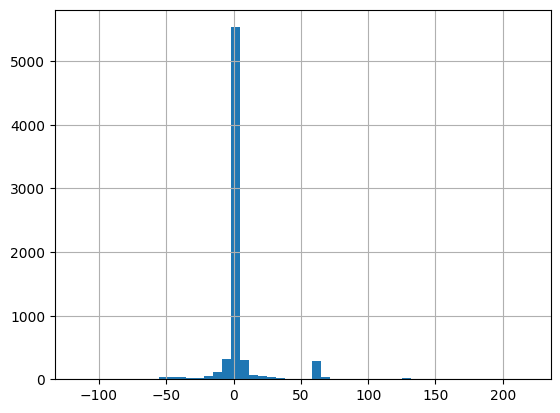

In [60]:
payments["dias_atraso"].hist(bins=50)

## Preliminary Default Classification

Creating an initial default flag based on payment delay and missing payment dates.

In [63]:
payments["flag_inadimplente"] = (
    payments["dt_pagamento"].isna() |
    (payments["dias_atraso"] > 5)
)
payments["flag_inadimplente"].mean()

np.float64(0.11744872155099748)

## Dataset Enrichment

Joining payment data with auxiliary company information.

In [64]:
df_join = payments.merge(
    auxiliary,
    left_on="id_pagador",
    right_on="id_cnpj",
    how="left"
)

## Default Rate by State

Analyzing default behavior across states.

In [65]:
df_join.groupby("uf")["flag_inadimplente"] \
    .mean() \
    .sort_values(ascending=False)

,flag_inadimplente
uf,
PA,0.448000
SC,0.293793
TO,0.285714
RN,0.250000
PB,0.210526
SE,0.208333
CE,0.161765
PI,0.148148
AC,0.125000


## Payment Frequency per Payer

Analyzing concentration and recurrence of payment activity.

In [66]:
payments["id_pagador"].value_counts().describe()

,count
count,3525.000000
mean,2.019291
std,7.907968
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,231.000000


## Monthly Distribution of Payments

Evaluating temporal distribution of payment receipts.

In [67]:
payments.groupby(
    payments["dt_vencimento"].dt.to_period("M")
).size()

,0
dt_vencimento,
2024-05,7118


## Financial Value vs Default Behavior

Comparing nominal values between defaulted and non-defaulted payments.

In [68]:
payments.groupby("flag_inadimplente")["vlr_nominal"].describe()

,count,mean,std,min,25%,50%,75%,max
flag_inadimplente,,,,,,,,
False,6282.0,24307.418489,84990.035449,7.94,522.2775,1884.585,10216.1375,3294630.00
True,836.0,15734.790837,70502.518982,5.24,126.0700,689.810,4559.1750,1284118.86


## Outlier Investigation

Inspecting highest nominal payment values.

In [69]:
payments.nlargest(10, "vlr_nominal")[
    ["id_boleto", "vlr_nominal"]
]

,id_boleto,vlr_nominal
3317,a7e287a4e42fa97d9fe805ffb73b3790349ba3a0f50bf0...,3294630.00
4171,c775d2ae959d5c1f72df8072b334b2180727ee2eedf796...,1964862.43
6099,f12f0abee211d549303724b131793b72b6e6e4a21ca53f...,1284118.86
98,245bf6b845d688ab64e4392156b29d6a6db574f36b32e7...,1152833.44
6851,5557c2070437f5961736a58bd5a210f7f30fb22c24ca50...,1019818.73
1750,10f1f5210579ed190734e0218f47805f632ec279c06156...,951590.45
2909,dde7e08608f86d9ead00eaa77a4c821703289c25ed9d64...,951590.45
4569,8accfd773ae72a6a1a6e61b04860db407225f37a5aa958...,951590.45
600,f3e26b177aef9393868e0f930b6837f7ec1954093925df...,888476.10
6738,f50901ca2c091601581210f89e67ce02c80a8974f850f8...,812458.93


# Main Findings

- Most payment records are structurally complete
- `dt_pagamento` null values likely represent unpaid or open payments
- `vlr_baixa` contains a significant proportion of null values and may represent operational settlement behavior
- Payment delays include both early and late payments
- All payer and beneficiary identifiers were found in the auxiliary dataset
- Financial values present strong asymmetry with large outliers
- Default behavior varies across states